# Imports

In [64]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_sig_stats

1. Identify Age-Driver Transcription Factors

Use the model to rank TFs based on their predicted ability to accelerate or reverse aging signatures in specific PBMC subtypes.
	•	Highlight TFs whose perturbation causes large positive or negative shifts in predicted age.
	•	Compare across cell types to find universal vs. cell-type-specific aging regulators.

2. Compare Aging Across Subtypes

Quantify how sensitive different PBMC subtypes are to the same TF perturbation in terms of age shift.
	•	Some cell types may be more “reversible” than others.
	•	Useful for understanding which immune compartments are more plastic with age.
3. Screen for Rejuvenation Targets

Identify TFs whose in-silico perturbation shifts aged cells toward a younger profile.
	•	Create a short list of candidate rejuvenation TFs.
	•	Cross-check with known interventions (e.g., Yamanaka factors, caloric restriction).

4. Contextualize Disease-Aging Interactions

Apply the model to PBMCs from individuals with age-related diseases (e.g., SLE, Alzheimer’s).
	•	Identify TF perturbations that reverse disease-induced age acceleration.
	•	Find disease-specific TFs that exaggerate or mitigate aging responses.

5. Build Age-Trajectory Maps

Use the predicted age shifts to construct pseudo-time trajectories showing how perturbations could reshape aging progression.
	•	Map TF-induced age “paths” across time.
	•	Reveal nonlinear dynamics or tipping points.

6. Link to Epigenetics / Accessibility Data

If you have ATAC-seq or chromatin data, use it to:
	•	Check if predicted rejuvenating TFs show increased accessibility in younger cells.
	•	Prioritize TFs that are both functional in the model and epigenetically poised.

# Single TF perturbation

In [ ]:
perturbation_mode = 'overexpression' # 'overexpression' # 'natural_aging' for aging clock, 'overexpression' for overexpression perturbation
save_file=f"{save_dir}/perturbation/tf_screen_results_{perturbation_mode}.csv"
if True: # single
    from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening
    from ciim.src.common import save_dir
    par = {
        'years': 10,
        'n_donors': 1, # select only one donor for linear models
        'data_type': 'bulk',
        'version': 'v1.0',
        'reg_type': 'ridge',
        'feature_type': 'gene_expression',
        'perturbation_mode': perturbation_mode, # natural_aging, overexpression
        'perturbation_type': 'single',
        'tfs': None,  # None means all TFs
        
    }
    datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese'] #['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']
    cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
    perturb_rr = wrapper_run_tf_screening(par, 
                                    n_jobs=10,
                                    cell_types=cell_types,
                                    datasets=datasets 
                                    )
    
    perturb_rr.to_csv(save_file, index=False)
else:
    perturb_rr = pd.read_csv(save_file)
    print(f"Loaded {len(perturb_rr)} results from {save_file}")
    print(perturb_rr.head())

Processing: CD8T - SLE_European (overexpression | single)
Processing: MONO - data1 (overexpression | single)
Processing: CD8T - data13_Japanese (overexpression | single)
Processing: CD4T - data1 (overexpression | single)
Processing: CD8T - data1 (overexpression | single)
Processing: MONO - data7_allTPs_jalil (overexpression | single)
Processing: CD4T - data7_allTPs_jalil (overexpression | single)
Processing: CD8T - data7_allTPs_jalil (overexpression | single)
Processing: CD4T - SLE_European (overexpression | single)
Processing: CD4T - data13_Japanese (overexpression | single)
Processing: MONO - SLE_European (overexpression | single)
Processing: MONO - data13_Japanese (overexpression | single)
Processing: B - data1 (overexpression | single)


In [112]:
perturb_rr[perturb_rr['cell_type']=='MONO'].groupby('tf').size().sort_values(ascending=False)

tf
ZFHX3      4
ETV6       4
FAM200B    4
TET2       4
FOS        4
          ..
ZBTB40     1
ZBTB43     1
ZBTB45     1
KAT7       1
ZZZ3       1
Length: 577, dtype: int64

### Check the normality of age shift

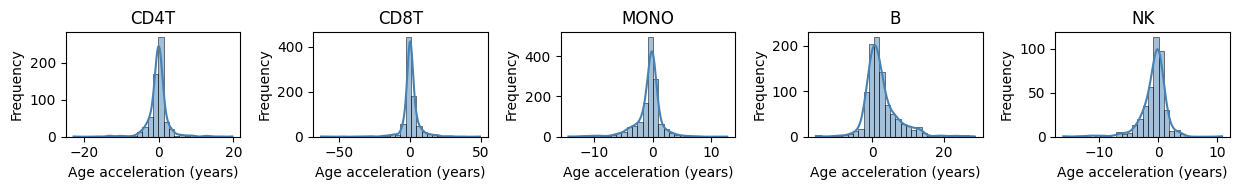

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr[perturb_rr['cell_type'] == cell_type].copy()
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Significance of age acceleration per TF

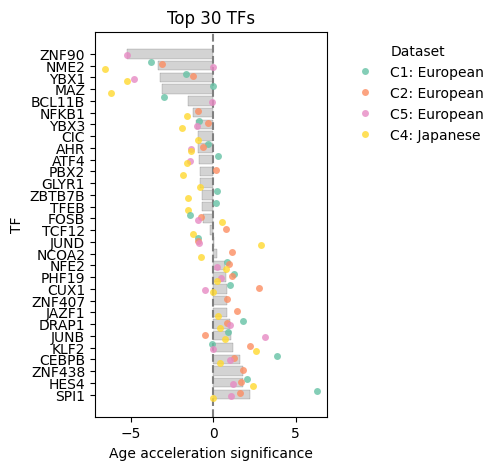

In [98]:
from ciim.src.insilico_perturbation.helper import wrapper_plot_age_acceleration_for_tf_perturbation

cell_type = 'MONO'
features = None

perturb_rr_t = perturb_rr[perturb_rr['cell_type'] == cell_type].copy()

aa = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_t, value_col='signed_neg_log10_pval', top_n=30)

In [109]:
df_cell = perturb_rr_t.copy()
value_col = 'signed_neg_log10_pval'
top_n = 30

median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())
top_tfs = median_abs.sort_values(ascending=False).head(top_n).index

# Keep only top TFs
df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

# Sort TFs by signed mean_diff for plotting
tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
df_cell['tf'].cat.categories

Index(['ZNF90', 'NME2', 'YBX1', 'MAZ', 'BCL11B', 'NFKB1', 'YBX3', 'CIC', 'AHR',
       'ATF4', 'PBX2', 'GLYR1', 'ZBTB7B', 'TFEB', 'FOSB', 'TCF12', 'JUND',
       'NCOA2', 'NFE2', 'PHF19', 'CUX1', 'ZNF407', 'JAZF1', 'DRAP1', 'JUNB',
       'KLF2', 'CEBPB', 'ZNF438', 'HES4', 'SPI1'],
      dtype='object', name='tf')

Only 5 datasets are available in the stats.
True


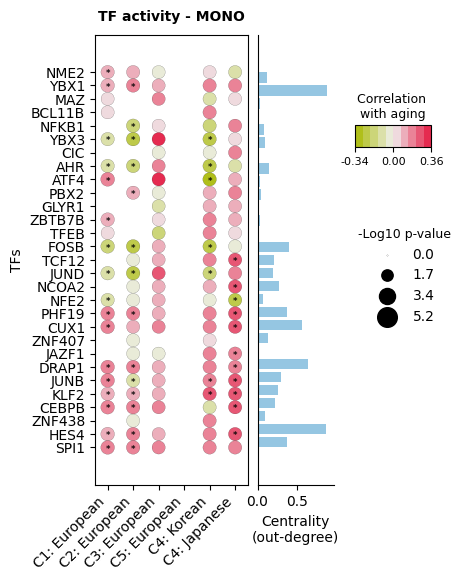

In [110]:
features = df_cell['tf'].cat.categories
from ciim.src.tf_activity.plots import plot_features_vs_datasets
bb = plot_features_vs_datasets(cell_type='MONO', type=type, datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': 0.1})

## Consistency of the age shift with aging TFs 

In [86]:
perturb_rr

,mean_diff,tf,cell_type,dataset,perturbation,perturbation_type,z_score,empirical_pval_two_sided,signed_neg_log10_pval
0,0.150292,CAMTA1,CD4T,data1,overexpression,single,0.087588,0.930204,0.031422
1,0.000000,CENPS,CD4T,data1,overexpression,single,0.037475,0.970106,0.000000
2,1.123358,E2F2,CD4T,data1,overexpression,single,0.412043,0.680308,0.167294
3,1.510591,RUNX3,CD4T,data1,overexpression,single,0.541160,0.588397,0.230330
4,-2.128422,ZNF683,CD4T,data1,overexpression,single,-0.672218,0.501445,-0.299777
...,...,...,...,...,...,...,...,...,...
4149,2.910808,ZNF683,NK,data13_Japanese,overexpression,single,1.570263,0.116354,0.934219
4150,-0.872367,ZNF800,NK,data13_Japanese,overexpression,single,-0.033822,0.973019,-0.011879
4151,-0.855624,ZNF853,NK,data13_Japanese,overexpression,single,-0.026723,0.978681,-0.009359
4152,-0.674517,ZNF92,NK,data13_Japanese,overexpression,single,0.050067,0.960069,-0.017698


In [84]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
perturb_slope_sign = (
    perturb_rr.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)

# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk')
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    aaa
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='left')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'fraction_matched': fraction_matched
    })

# Convert to DataFrame
overlap_df = pd.DataFrame(overlap_results)
overlap_df

NameError: name 'aaa' is not defined

## Donor level plot

In [5]:
from ciim.src.insilico_perturbation.helper import perform_stat_test, plot_age_acceleration_donors
# format the data for test
cell_type = 'MONO'
dataset = 'data12'
ctr='Unperturbed'
treatment='Perturbed'

df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
p_value, slope = perform_stat_test(df_pivot, ctr=ctr, treatment=treatment)
plot_age_acceleration_donors(df_pivot, ctr=ctr, treatment=treatment)


NameError: name 'obs_all' is not defined

# Multivariate perturbation

In [68]:
def retrieve_sig_stats_drug(cell_type, ctrl, condition, feature_type='tf_activity', dataset='CXCL9', test_type= 'paired', type = 'bulk'):
    # - retrieve stats of tf association with drugs
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    stats_drug_sig = stats_drug[(stats_drug['cell_type']==cell_type) & (stats_drug['p_value_adj']< 0.05) & (stats_drug['ctrl'] == ctrl) & (stats_drug['condition'] == condition)].copy()
    return stats_drug_sig
def get_overlapping_tf_slopes_in_perturbation_and_aging(stats_drug_sig):
    # - retrieve sig stats
    stats_aging_sig = retrieve_sig_stats(type=type).drop_duplicates(subset=['cell_type', 'tf'])
    stats_aging_sig = stats_aging_sig[(stats_aging_sig['cell_type'] == cell_type)].copy()

    # - find the overlapping tfs
    aging_tfs = set(stats_aging_sig['tf'])
    drug_tfs = set(stats_drug_sig['tf'])
    overlapping_tfs = aging_tfs.intersection(drug_tfs)
    print(f"Overlapping TFs in {cell_type}: {len(overlapping_tfs)}")

    # - get the slop of the overlapping tfs
    df_slope = stats_drug_sig_t[stats_drug_sig_t['tf'].isin(overlapping_tfs)].set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope']]
    return df_slope

Overlapping TFs in CD8T: 63
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)
Overlapping TFs in CD8T: 1
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)
Overlapping TFs in CD8T: 0
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - 

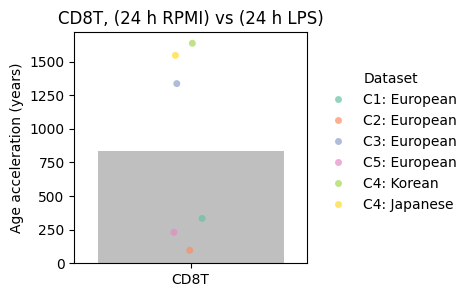

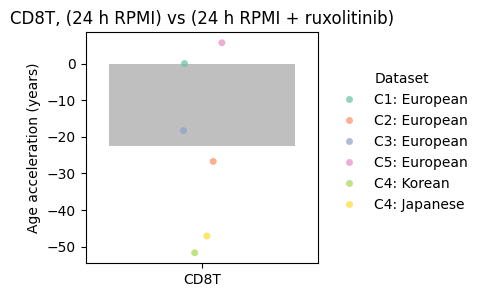

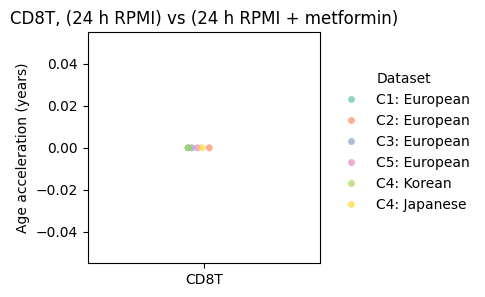

In [74]:
# - get significant stats for drug perturbation
cell_type = 'CD8T'
# ctrl = '24 h RPMI'
# condition = '24 h LPS'  #'24 h LPS + ruxolitinib'

for ctrl in ['24 h RPMI']:
    for condition in ['24 h LPS', '24 h RPMI + ruxolitinib', '24 h RPMI + metformin']:
        stats_drug_sig = retrieve_sig_stats_drug(cell_type, ctrl, condition)
        df_slope = get_overlapping_tf_slopes_in_perturbation_and_aging(stats_drug_sig)

        # - multivariate perturbation
        from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration
        par = {
            'years': 10,
            'n_donors': 1,
            'data_type': 'bulk',
            'version': 'v1.0',
            'reg_type': 'ridge',
            'feature_type': 'gene_expression',
            'perturbation_mode': 'overexpression',
            'perturbation_type': 'multi',
            'slope_df': df_slope,
        }
        df_all = wrapper_run_tf_screening(par, 
                                    n_jobs=1,
                                    cell_types=[cell_type],
                                    datasets=datasets_all,
                                    )
        fig = plot_age_acceleration(df_all)
        plt.title(f"{cell_type}, ({ctrl}) vs ({condition})")